# Calculate 2-point correlations as function of separation

In [26]:
from src.fatemarkers import FateMarkers

import matplotlib
import matplotlib.pyplot as plt

from nonlocal_correlations import *

## Load organoid mesh and build laplacian

For illustration purposes we just treat a single organoid 

In [27]:
data_dir = '../NicoleData/20250714/fractal_output'

# choose one timepoint/well/round
timepoint = "day4p5"
zarr_name = "r0.zarr"
well = "A06"
round_name = "0_fused_zillum"
organoid_id = 19  # example


path = f"{data_dir}/{timepoint}/{zarr_name}/{well[0]}/{well[1:]}/{round_name}/meshes/nnorg_linked_annotated/{organoid_id}.vtp"


# Process mesh
m = FateMarkers()
m.load_mesh_from_file(path)
m.align_with_pca()
_, coeffs_fields = m.compute_coefficients(lmax=15)
L, M = build_cotangent_laplacian_and_mass(m.v, m.f)

_, patch_centers = get_patch_centers(m.v, m.fields[:,0])
vertex_areas = np.array(M.diagonal())

volume = mesh_volume_from_triangles(m.v, m.f)

# Process fields
hks = m.compute_hks_for_new_times(new_ts=[4.0], coeffs=False)
coeffs_hks = m.compute_hks_for_new_times(new_ts=[4.0], coeffs=True)

vertex_fields = np.concatenate([hks, m.fields[:,3::2]], axis=1)
_, cell_areas, cell_weighted_fields, _, _ = per_cell_stats_from_vertex_labels(m.v, m.f, vertex_areas, m.fields[:,0], vertex_fields)
vertex_fields = vertex_fields[patch_centers, :]


In [28]:
# Process geodesics
dist_heat_cpu = heat_geodesic_all_sources(m.v, m.f, L, M, t=None, sources=patch_centers)  # (S,V)

heat sources: 100%|██████████| 562/562 [00:02<00:00, 236.01it/s]


In [30]:
import numpy as np
import cupy as cp
from scipy.sparse.linalg import splu
from scipy import sparse

def heat_geodesic_all_sources_gpu(v, f, L, M, t=None, sources=None):
    """
    Fast GPU-accelerated Heat Method using CPU sparse solves and batched GPU dense computations.

    Parameters
    ----------
    v : (V,3) array
        Mesh vertices
    f : (F,3) array
        Mesh faces (triangles)
    L : (V,V) sparse
        Cotangent Laplacian
    M : (V,V) sparse
        Lumped mass matrix
    t : float, optional
        Heat time. If None, set ~ mean_edge_length^2
    sources : array of int, optional
        Indices of source vertices. If None, compute for all vertices

    Returns
    -------
    D_out : (S,V) array
        Geodesic distances from each source to all vertices
    """
    V = v.shape[0]
    F = f.shape[0]

    if sources is None:
        sources = np.arange(V, dtype=np.int32)
    else:
        sources = np.asarray(sources, dtype=np.int32)
    S = len(sources)

    # --- CPU sparse LU decompositions ---
    reg = 1e-12
    L_factor = splu((L + reg * sparse.eye(V, dtype=L.dtype)).tocsc())

    if t is None:
        edges = np.vstack([f[:, [0,1]], f[:, [1,2]], f[:, [2,0]]])
        edges = np.unique(np.sort(edges, axis=1), axis=0)
        mean_edge = np.mean(np.linalg.norm(v[edges[:,0]] - v[edges[:,1]], axis=1))
        t = mean_edge**2

    A_factor = splu((M + t*L).tocsc())

    # --- Move dense arrays to GPU ---
    G_face = build_G_face(v, f)           # (F,3,3)
    G_face_gpu = cp.asarray(G_face)

    tri = v[f]                             # (F,3,3)
    face_normals = np.cross(tri[:,1]-tri[:,0], tri[:,2]-tri[:,0])
    face_areas = 0.5 * np.linalg.norm(face_normals, axis=1)
    face_areas_gpu = cp.asarray(face_areas)

    # --- Build RHS for all sources ---
    delta = np.zeros((V, S), dtype=np.float64)
    delta[sources, np.arange(S)] = 1.0
    rhs = M @ delta  # (V,S)

    # --- Solve heat equation per source (CPU) ---
    U = np.zeros_like(rhs)
    for i in range(S):
        U[:, i] = A_factor.solve(rhs[:, i])

    # --- Move batch to GPU ---
    U_gpu = cp.asarray(U.T)  # (S,V)

    # --- Compute grad_u per face for all sources at once ---
    U_f = U_gpu[:, f]  # (S,F,3)
    grad_u = cp.einsum('sfa,fai->sfi', U_f, G_face_gpu)  # (S,F,3)

    # --- Normalize vector field ---
    norms = cp.linalg.norm(grad_u, axis=2)
    norms = cp.where(norms==0, 1e-12, norms)
    X_face = -(grad_u / norms[:,:,None])

    # --- Divergence accumulation ---
    contrib = cp.einsum('sfi,fai->sfa', X_face, G_face_gpu)
    contrib *= face_areas_gpu[None,:,None]

    # Accumulate divergence to vertices on CPU
    D_out = np.zeros((S, V), dtype=np.float64)
    contrib_cpu = cp.asnumpy(contrib)

    for s_idx in range(S):
        div = np.zeros(V, dtype=np.float64)
        for a in range(3):
            np.add.at(div, f[:, a], contrib_cpu[s_idx, :, a])
        # --- Solve Poisson (CPU) ---
        phi = L_factor.solve(div)
        phi -= phi[sources[s_idx]]
        D_out[s_idx, :] = phi

    return D_out


In [31]:
dist_heat_gpu = heat_geodesic_all_sources_gpu(m.v, m.f, L, M, t=None, sources=patch_centers)  # (S,V)

Max absolute difference: 3.694822225952521e-13
Mean absolute difference: 2.1134592782191873e-14


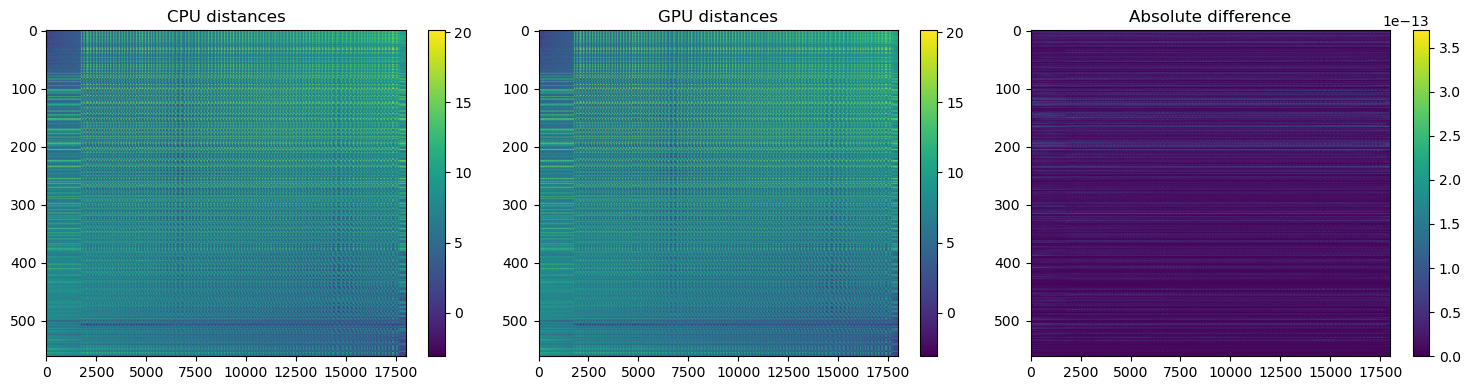

In [32]:
# --- Compare ---
diff = np.abs(dist_heat_cpu - dist_heat_gpu)

print("Max absolute difference:", diff.max())
print("Mean absolute difference:", diff.mean())

# --- Visualization ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

im0 = axes[0].imshow(dist_heat_cpu, aspect='auto')
axes[0].set_title('CPU distances')
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(dist_heat_gpu, aspect='auto')
axes[1].set_title('GPU distances')
plt.colorbar(im1, ax=axes[1])

im2 = axes[2].imshow(diff, aspect='auto')
axes[2].set_title('Absolute difference')
plt.colorbar(im2, ax=axes[2])

plt.tight_layout()
plt.show()